/tmp/ipykernel_17/2579122423.py:99: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


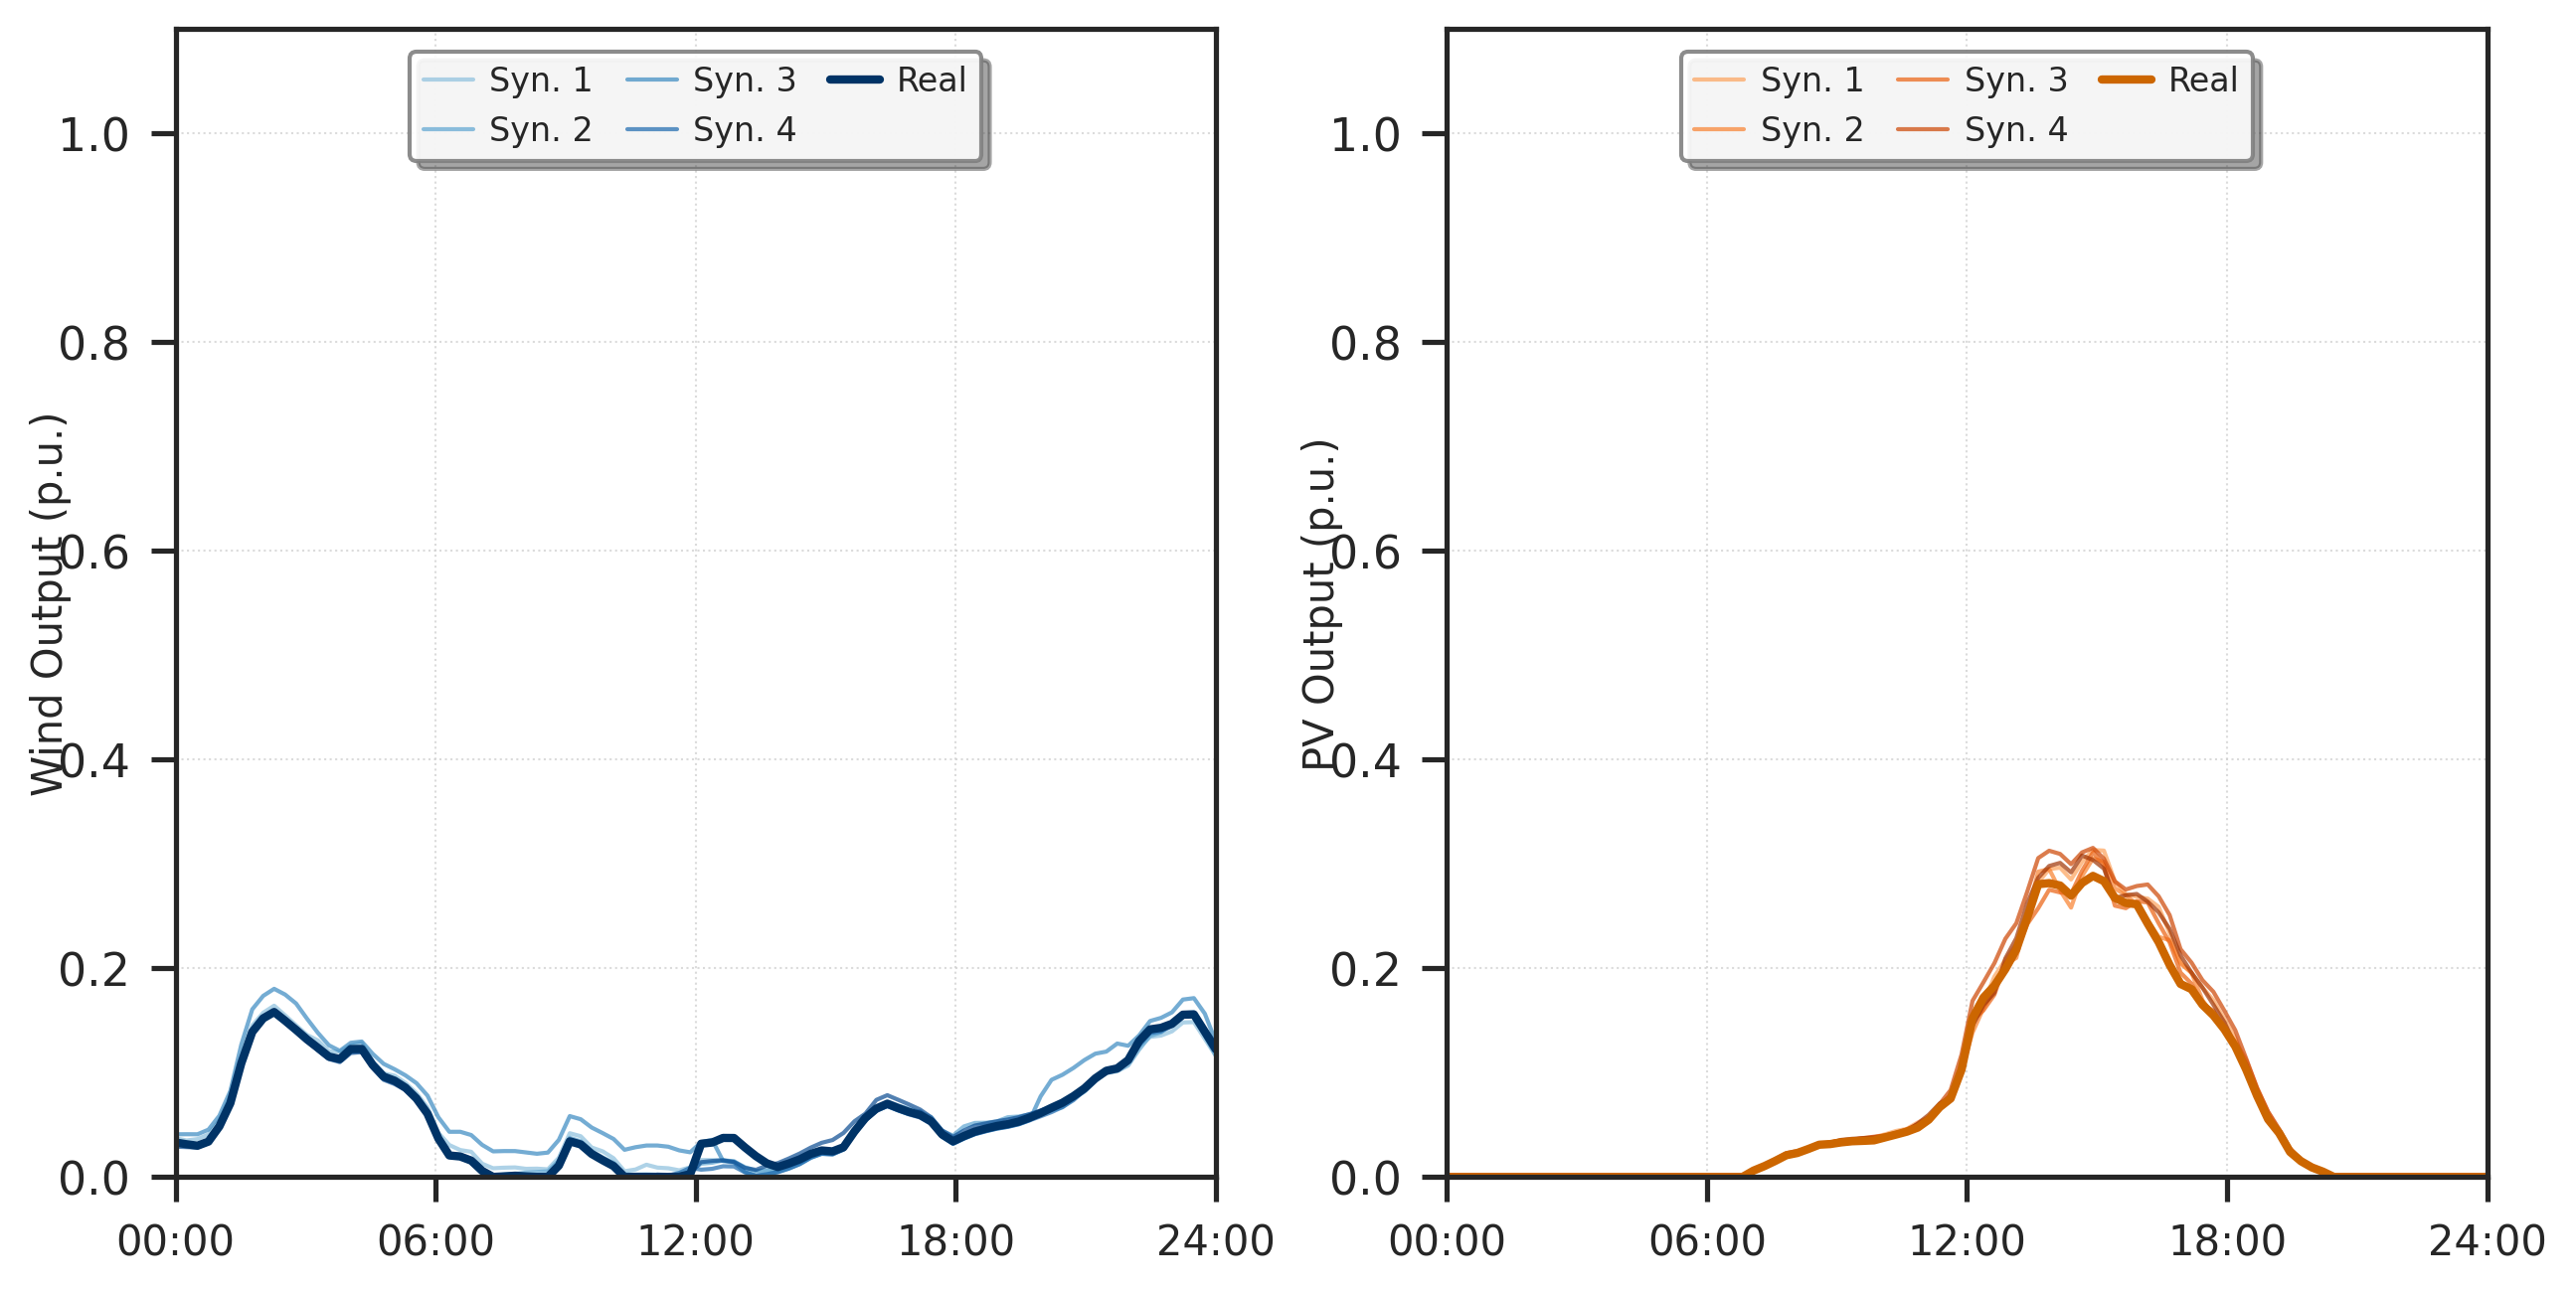

In [1]:
!pip install scienceplots
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import pandas as pd
import scienceplots
import seaborn as sns
from datetime import datetime, timedelta
from matplotlib.ticker import MultipleLocator

plt.rcParams['savefig.dpi'] = 300
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family']='Times New Roman'
plt.rcParams['axes.unicode_minus']= False
sns.set(style='ticks')
plt.style.use(sorted(plt.style.available)[31])


wind_series_500 = pd.read_csv("/kaggle/input/datasets/belovedorange/research-methodology-project/node_22_wind_actual.csv")
power_df = pd.read_csv("/kaggle/input/datasets/belovedorange/research-methodology-project/node_18_PV_actual.csv")

wind_syn = []
for i in range(5):
    syn = np.array(wind_series_500.iloc[:96,i+1])*1.5
    wind_syn.append(syn)
wind_real = np.array(wind_series_500.iloc[:96,6])*1.5 

PV_syn = []
for i in range(5):
    syn = np.array(power_df.iloc[:96,i+2])
    PV_syn.append(syn)
PV_real = np.array(power_df.iloc[:96,1])

time_points = 96
hours = np.linspace(0, 24, time_points)

fig = plt.figure(figsize=(10, 5))
grid = plt.GridSpec(20, 20, wspace=0, hspace=0)

# Wind plot (left)
ax1 = fig.add_subplot(grid[:, 0:9])
for i, syn in enumerate(wind_syn, 1):
    ax1.plot(hours, syn, color=plt.cm.Blues(0.3 + i*0.12), linewidth=1, alpha=0.7, 
             label=f'Syn. {i}' if i < 5 else None)
ax1.plot(hours, wind_real, color='#003366', linewidth=2, linestyle='-', label='Real')

# PV plot (right)
ax2 = fig.add_subplot(grid[:, 11:], sharey=ax1)
for i, syn in enumerate(PV_syn, 1):
    ax2.plot(hours, syn, color=plt.cm.Oranges(0.3 + i*0.12), linewidth=1, alpha=0.7,
             label=f'Syn. {i}' if i < 5 else None)
ax2.plot(hours, PV_real, color='#CC6600', linewidth=2, linestyle='-', label='Real')

# Common styling
for ax in [ax1, ax2]:
    ax.set_xticks([0, 6, 12, 18, 24])
    ax.set_xticklabels(['00:00', '06:00', '12:00', '18:00', '24:00'], fontsize=10)
    ax.set_xlim(0, 24)
    ax.set_ylim(0, 1.1)
    ax.yaxis.set_major_locator(MultipleLocator(0.2))
    ax.grid(True, which='both', linestyle=':', linewidth=0.5, alpha=0.7)
    
# Axis labels with adjusted padding to avoid overlap
ax1.set_ylabel('Wind Output (p.u.)', fontsize=10, labelpad=5)
ax2.set_ylabel('PV Output (p.u.)', fontsize=10, labelpad=5)
ax1.yaxis.set_label_coords(-0.10, 0.5)
ax2.yaxis.set_label_coords(-0.10, 0.5)

# Set x-axis labels with padding to avoid overlap with y-axis labels
ax1.set_xlabel('', fontsize=10, labelpad=8)
ax2.set_xlabel('', fontsize=10, labelpad=8)

# Adjust tick parameters to add some padding
ax1.tick_params(axis='both', which='major', pad=5)
ax2.tick_params(axis='both', which='major', pad=5)

# Updated legends - positioned inside plot at top with frame
legend_params = {
    'frameon': True,  # Enable frame
    'fancybox': True,  # Rounded corners
    'shadow': True,    # Add shadow
    'framealpha': 0.9, # Semi-transparent background
    'facecolor': 'white',  # White background
    'edgecolor': 'gray',   # Gray border
    'fontsize': 8,
    'ncol': 3,
    'bbox_to_anchor': (0.5, 0.98),  # Inside plot at top
    'loc': 'upper center',  # Anchor point at top of legend  
    'borderaxespad': 0.,    # No padding between legend and axes
    'columnspacing': 1.0,   # Space between columns
    'handlelength': 1.5,    # Length of legend handles
    'handletextpad': 0.5    # Padding between handle and text
}

ax1.legend(**legend_params)
ax2.legend(**legend_params)

plt.tight_layout()
plt.show()